# Advanced Artificial Intelligence Task 2: 
## Inference Example

In [ ]:
import sys
import os
import cv2
from matplotlib import pyplot as plt
from safetensors.torch import load_file
import torch
import random
import torch.nn as nn
from torchvision.models import get_model, get_weight
from PIL import Image
from pathlib import Path
import pickle
sys.path.append("..")
sys.path.append(".")
from utils.generate_masks import generate_produce_mask
from utils.grade_produce import grade_colour, grade_colour_generic, grade_proportion
from utils.mtl_model import MultiTaskClassifier
from utils.dataset import ProduceDataset
from experiment_configs import task_2_config as experiments


# Select experiment and trained weights path 
TRAINED_MODEL_PATH = Path(".") / "models" / "EX3_efficientnet_finetune_mtl_20260414183210.safetensors"
EXPERIMENT = experiments.EX3_EFFICIENTNET_FINETUNE_MTL
assert EXPERIMENT.display_name.lower() in TRAINED_MODEL_PATH.stem.lower(), \
        (f"Checkpoint '{TRAINED_MODEL_PATH.name}"
         f"doesn't match experiment '{EXPERIMENT.display_name}"
         )
PRODUCE_DATESET_PATH = Path(".") / "data" / "Fruit_And_Vegetable_Diseases_Dataset"
# Type threshold given the limited number of produce types
# Inputs below the threshold will be considered "Uknown"
TYPE_CONFIDENCE_THRESHOLD = 50


# Load empty model architecture (without pretrained weights)
# Build the same MTL wrapper used during training
base_model = get_model(EXPERIMENT.architecture, weights=None)
produce_dataset = ProduceDataset(dataset_root_dir=PRODUCE_DATESET_PATH, 
                                 transform=None)

if EXPERIMENT.is_mtl:
    # MTL: instantiate custom MTL with auxillary produce type objective
     # Need num_types to match training - get from dataset
    model = MultiTaskClassifier(base_model, 
                                num_produce_classes=produce_dataset.num_produce_types)
else:
    # STL: replace the final classifier for binary health classification
    num_features = base_model.classifier[1].in_features
    base_model.classifier[1] = nn.Linear(num_features, 2)
    model = base_model

# Load trained weights into the MTL wrapper
if os.path.splitext(TRAINED_MODEL_PATH)[1] == ".pth":
    model.load_state_dict(torch.load(TRAINED_MODEL_PATH, weights_only=True))
else: # Load as safetensor
    state_dict = load_file(TRAINED_MODEL_PATH)
    model.load_state_dict(state_dict)

# Send to device and set model to eval mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Get transforms for inference input
pretrained_weights = get_weight(EXPERIMENT.weight_string)
auto_transforms = pretrained_weights.transforms()

# Define the target classes
health_names = ['Healthy', 'Rotten']
type_names = produce_dataset.produce_type_names

def classify_produce(image_path):
    """
    Classify a single image of produce.
    Returns the predicted health label and confidence
    If the model is MTL, fruit type and type confidence is aditionally returned.
    """
    image = Image.open(image_path).convert("RGBA").convert("RGB")
    input_tensor = auto_transforms(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        if EXPERIMENT.is_mtl:
            health_output, type_output = model(input_tensor)
        else:
            health_output = model(input_tensor)
        
        # Health prediction
        health_probs = torch.nn.functional.softmax(health_output, dim=1)[0]
        health_pred_id = health_probs.argmax().item()
        health_confidence = health_probs[health_pred_id].item() * 100
        
    health_label = health_names[health_pred_id]
    print(f"Health: {health_label} ({health_confidence:.1f}%)")

    result = {
    "health_label": health_label,
    "health_confidence": health_confidence,
    "fruit_type": None,
    "type_confidence": None,
    "known_type": None,
    }

    if EXPERIMENT.is_mtl:
        # Type prediction
        type_probs = torch.nn.functional.softmax(type_output, dim=1)[0]
        type_pred_id = type_probs.argmax().item()
        type_confidence = type_probs[type_pred_id].item() * 100

        fruit_type = type_names[type_pred_id]
        known = type_confidence >= TYPE_CONFIDENCE_THRESHOLD
        result["fruit_type"] = fruit_type if known else "unknown"
        result["type_confidence"] = type_confidence
        result["known_type"] = known
        print((f"Type:   {result['fruit_type']} ({type_confidence:.1f}%)" 
               f"{'' if known else f'({fruit_type} - {TYPE_CONFIDENCE_THRESHOLD-type_confidence:.1f} below threshold)'}"))
        
    return result

def grade_produce(image_path, color_references=None, colour_distribution=None, 
                  grade_colour_vs_ref = False, preview_img=True) -> dict:
    """
    Determine grading based on ripeness, colour and proportion.
    Ripeness    - Softmax prediction confidence from classify_produce()
    Colour      - STL/fallback: Score of saturation/vividty (OpenCV) 
                - MTL: HSV histogram similarity vs known produce healthy reference (OpenCV) 
    Proportion  - Contour solidity (OpenCV)
    """
    mask = generate_produce_mask(str(image_path), method="rembg")
    if preview_img:
        img = Image.open(image_path)
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(img)
        axes[0].set_title("Original")
        axes[0].axis("off")
        
        # Resize mask to match image if needed
        mask_display = cv2.resize(
            mask, (img.width, img.height), 
            interpolation=cv2.INTER_NEAREST) if mask.shape[:2] != (img.height, img.width) else mask
        axes[1].imshow(mask_display, cmap="gray")
        axes[1].set_title("Segmentation Mask")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()

    # Ripeness: use confidence from ML classification
    classification = classify_produce(image_path)
    label = classification["health_label"]
    fruit_type = classification["fruit_type"]

    # If healthy, confidence = ripeness; rotten, invert.
    ripeness_score = (
        classification["health_confidence"]
        if label == "Healthy"
        else 100 - classification["health_confidence"]
    )

    # Always compute generic score to show as baseline

    generic_score, vibrancy, uniformity = grade_colour_generic(
        image_path, colour_distribution, mask=mask)

    if classification.get("known_type") and color_references and grade_colour_vs_ref:
        # Known type => gauge colour score from known standard
        colour_score = grade_colour(image_path, fruit_type,
                                     color_references, mask=mask)
    else:
        # Unknown/STL => fall back to generic score
        colour_score = generic_score

    proportion_score = grade_proportion(image_path, mask=mask)
    
    scores = {
        "ripeness": ripeness_score,
        "colour": colour_score,
        "size": proportion_score,
    }

    # Grade thresholds: must meet ALL minimums for that grade
    thresholds = [
        ("A", {"colour": 85, "size": 90, "ripeness": 80}),
        ("B", {"colour": 75, "size": 80, "ripeness": 70}),
        ("C", {"colour": 65, "size": 70, "ripeness": 60}),
    ]

    if label == "Rotten":
        grade = "Rejected"
    else:
        grade = "D"  # default if no threshold met and not rotten
        for threshold_grade, minimums in thresholds:
            if all(scores[key] >= minimums[key] for key in minimums):
                grade = threshold_grade
                break

    if classification.get("known_type"):
        colour_detail = f"(Hist similarity to reference; generic: {int(generic_score)}%)"
    else:
        colour_detail = f"(Vibrancy: ({vibrancy:.2f}); uniformity: ({uniformity:.2f}))"

    explanation = (
        f"{'Grade:':<12}{grade}\n"
        f"{'Ripeness:':<12}{int(ripeness_score)}% (Healthy confidence)\n"
        f"{'Colour:':<12}{int(colour_score)}% {colour_detail}\n"
        f"{'Proportion:':<12}{int(proportion_score)}% (contour)"
    )
    return {
        "prediction": label,
        "fruit_type": fruit_type,
        "ripeness_score": ripeness_score,
        "color_score": colour_score,
        "generic_colour_score": generic_score,
        "proportion_score": proportion_score,
        "overall_grade": grade,
        "explanation": explanation,
    }

Health: Healthy (86.9%)
Type:   unknown (9.5%)(banana__healthy - 40.5 below threshold)
RAW - Vib: 0.38, Uni: 0.46


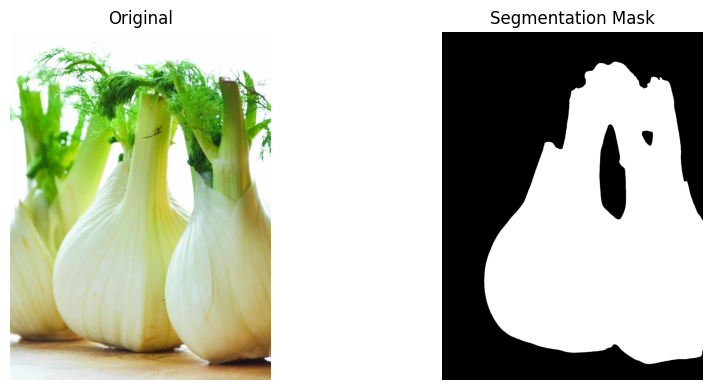

Health: Healthy (86.9%)
Type:   unknown (9.5%)(banana__healthy - 40.5 below threshold)
RAW - Vib: 0.38, Uni: 0.46
data/test_data/three-fennel-bulbs.jpg

Grade:      D
Ripeness:   86% (Healthy confidence)
Colour:     3% (Vibrancy: (0.03); uniformity: (0.03))
Proportion: 95% (contour)


In [ ]:
ood_test = True
show_healthy = False
show_correct = False

# Load references once
ref_path = Path(".") / "data" / "colour_references_rembg.pkl"
dist_path = Path(".") / "data" / "generic_colour_distribution.pkl"
with open(ref_path, "rb") as f:
    colour_references = {k.lower(): v for k, v in pickle.load(f).items()}
with open(dist_path, "rb") as f:
    colour_distribution = {k.lower(): v for k, v in pickle.load(f).items()}

while True:
    if ood_test:
        test_image_dir = Path(".") / "data" / "test_data"
        images = [f for f in os.listdir(test_image_dir)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
        rdm_test_image = test_image_dir / random.choice(images)
    else:
        test_img_dir = Path(".") / "data" / "Fruit_And_Vegetable_Diseases_Dataset"
        rdm_class_dir = test_img_dir / random.choice(os.listdir(test_img_dir))
        rdm_test_image = rdm_class_dir / random.choice(os.listdir(rdm_class_dir))

    result = grade_produce(rdm_test_image, colour_references, colour_distribution,
                           preview_img=False)

    type_ok = not show_correct or result.get("fruit_type") != "unknown"
    health_ok = not show_healthy or result.get("prediction") != "Rotten"

    if ood_test or (type_ok and health_ok):
        result = grade_produce(rdm_test_image, colour_references, colour_distribution, 
                               grade_colour_vs_ref=False, preview_img=True)
        break

print(rdm_test_image)
print("\n" + result['explanation'])
